# SPR data models
This notebook is to collaborate on modelling enzyme kinetics on SPR data.

## Reversible and irreversible binding model
ref: https://pubmed.ncbi.nlm.nih.gov/22966968/

$$
E_{bulk} + \Gamma_O \underset{k_{\text{off}}}{\overset{k_{\text{on}}}{\leftrightarrows}} \Gamma_E \overset{k_I}{\rightarrow} \Gamma_I
$$

In [13]:
#@title  **import packages and define functions**</font>
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.integrate import odeint
import os

def process_data(time, R, time_max=3600, plot_this=False):
    time_cut = time[time < time_max]
    R_cut = R[time < time_max]

    xmin=0

    # Optional: Smooth the data to reduce noise using Savitzky-Golay filter
    window_length = 51  # Must be an odd number; adjust as needed
    polyorder = 3
    R_cut_smooth = savgol_filter(R_cut, window_length, polyorder)

    if plot_this:
    # Plot the original and smoothed data to visualize smoothing effect
        plt.figure(figsize=(10, 6))
        plt.plot(time_cut, R_cut, label='Original Data', alpha=0.5)
        plt.plot(time_cut, R_cut_smooth, label='Smoothed Data', linewidth=2)
        plt.xlabel('Time')
        plt.ylabel('Signal')
        plt.title('Signal vs Time (Cut Data)')
        plt.legend()
        plt.grid(True)
        plt.show()

    # Step 2: Calculate the derivative of the smoothed data
    dR_dt = np.gradient(R_cut_smooth, time_cut)

    if plot_this:
    # Plot the derivative to visualize where the signal starts to rise
        plt.figure(figsize=(10, 6))
        plt.plot(time_cut, dR_dt)
        plt.xlabel('Time')
        plt.ylabel('dR/dt')
        plt.title('Derivative of Signal vs Time')
        plt.grid(True)
        plt.show()

    # Set a threshold for the derivative to detect where the baseline ends
    # Adjust the threshold based on your data characteristics
    threshold = np.max(dR_dt) * 0.2  # For example, 20% of the maximum derivative

    # Find the index where the derivative first exceeds the threshold
    baseline_end_indices = np.where(dR_dt > threshold)[0]

    if len(baseline_end_indices) > 0:
        baseline_end_index = baseline_end_indices[0]
        t_baseline_end = time_cut[baseline_end_index]
        print(f"Automatically detected t_baseline_end at time {t_baseline_end}")
    else:
        print("Could not automatically detect t_baseline_end; defaulting to xmin")
        t_baseline_end = xmin

    # Step 3: Normalize the data using R_normalized(t) = (R(t) - R_baseline) / (R_max - R_baseline)
    # Calculate R_baseline as the mean of R_cut during the baseline period
    baseline_indices = np.where(time_cut <= t_baseline_end)
    R_baseline = np.mean(R_cut[baseline_indices[0]])

    # Calculate R_max as the maximum value of R_cut after the baseline
    post_baseline_indices = np.where(time_cut > t_baseline_end)
    R_max = np.max(R_cut[post_baseline_indices[0]])

    # Normalize R(t)
    R_normalized = (R_cut - R_baseline) / (R_max - R_baseline)

    # Step 4: Cut off the initial flat (baseline) part
    # Extract data after t_baseline_end
    time_final = time_cut[post_baseline_indices[0]]
    R_normalized_final = R_normalized[post_baseline_indices[0]]

    # Rescale the time axis to start at zero at t_baseline_end
    time_rescaled = time_final - t_baseline_end
    t_signal_start = np.gradient(R_normalized_final, time_rescaled).argmax()
    R_normalized_final_tmp = R_normalized_final.values[t_signal_start:]
    while R_normalized_final_tmp[0]>0.1:
        t_signal_start -= 1
        R_normalized_final_tmp = R_normalized_final.values[t_signal_start:]
    time_rescaled = time_rescaled.values[t_signal_start:]
    R_normalized_final = R_normalized_final_tmp

    if plot_this:
    # Plot the final normalized data with rescaled time axis
        plt.figure(figsize=(10, 6))
        plt.plot(time_rescaled, R_normalized_final)
        plt.xlabel('Time since baseline end')
        plt.ylabel('Normalized Signal')
        plt.title('Normalized Signal vs Time (After Baseline Removal)')
        plt.grid(True)
        plt.show()
    return time_rescaled, R_normalized_final, R_max


def universal_enzyme_ode(y, t, ka, kd, ki, Gamma_max, transition_time):
    Gamma_E, Gamma_I = y
    Gamma_0 = Gamma_max - Gamma_E - Gamma_I
    
    # Concentration drops to 0 after transition_time (washoff)
    C = E_bulk if t < transition_time else 0.0

    if model_type == "M1":
        # E + S <-> ES 
        dGamma_E_dt = ka * C * Gamma_0 - kd * Gamma_E
        dGamma_I_dt = 0.0

    elif model_type == "M2":
        # E + S <-> ES -> ESi 
        dGamma_E_dt = ka * C * Gamma_0 - (kd + ki) * Gamma_E
        dGamma_I_dt = ki * Gamma_E
        
    elif model_type == "M3":
        # Mixed: M1 and M4
        dGamma_E_dt = ka * C * Gamma_0 - kd * Gamma_E
        dGamma_I_dt = ki * C * Gamma_0 
        
    elif model_type == "M4":
        # E + S -> ESi 
        dGamma_E_dt = 0.0
        dGamma_I_dt = ka * C * Gamma_0
        

    return [dGamma_E_dt, dGamma_I_dt]

def simulate_adsorption_washoff(t, ka, kd, ki, Gamma_max, transition_time):
    y0 = [0.0, 0.0]
    if model_type == "M1":
        ki = 0.0
    if model_type == "M4":
        kd = 0.0
        ki = 0.0
    solution = odeint(universal_enzyme_ode, y0, t, 
                      args=(ka, kd, ki, Gamma_max, transition_time))
    
    # Total surface enzyme
    Gamma_T = solution[:, 0] + solution[:, 1]
    return Gamma_T




def MSE(params,x_data,y_data):
    "to calclate mean square error, this is the same as your func_error"
    return ((simulate_adsorption_washoff(x_data,*params)-y_data)**2).mean()

def fit_model(time_rescaled, R_normalized_final, plot_this=False):
    # Define the ODE system based on equations 2 and 3

    besterror = 10000
    bestpopt = None
    low_ki,high_ki = (0,0.1)
    high_kd = 0.1
    kd_guess = 0.01
    ki_guess = 0.0
    for kon_ in np.arange(2000,20000,1000):
        for tt_ in np.arange(400,1400,20):
            # grid search for parameter c between 5 and 100, step size is 1.
            if model_type in ["M1", "M4"]:
                high_ki = 0.000001
            if model_type == "M4":
                high_kd = 0.000001
                kd_guess = 0.0
            if model_type == "M3":
                low_ki = kon_
                high_ki = kon_+1000
                ki_guess = kon_
                
            
            popt, pcov = curve_fit(simulate_adsorption_washoff,
                            time_rescaled,
                            R_normalized_final,
                            p0=[kon_, kd_guess, ki_guess, 1.0 , tt_],  # Initial guesses for ka, kd, ki, Gamma_max, transition_time
                            bounds=([kon_, 0,low_ki,0 , tt_], [kon_+1000, high_kd, high_ki, 2.0, tt_+1]))  # Reasonable bounds

            error = MSE(popt,time_rescaled,R_normalized_final)
            if error<besterror:
                besterror = error
                bestpopt = popt

    return bestpopt, error

    # Fit the entire dataset with a single set of parameters

def plot_best_popt(bestpopt, x_data, y_data):

    ka_fitted, kd_fitted, ki_fitted, Gamma_max_fitted, transition_time_fitted = bestpopt
    print(f"Fitted parameters:")
    print(f"kon (M-1 s-1): {ka_fitted:.6f}")
    print(f"koff (s-1): {kd_fitted:.6f}")
    print(f"ki (s-1): {ki_fitted:.6f}")
    print(f"Gamma_max: {Gamma_max_fitted:.6f}")
    print(f"transition_time (s): {transition_time_fitted:.6f}")


    error = MSE(bestpopt, x_data, y_data)
    print(f"MSE: {error:.6f}")


    # Decompose the result to show Gamma_E and Gamma_I separately
    solution = odeint(universal_enzyme_ode, y0=[0, 0], t=x_data, args=(ka_fitted, kd_fitted, ki_fitted, Gamma_max_fitted, transition_time_fitted))
    Gamma_E = solution[:, 0]
    Gamma_I = solution[:, 1]
    Gamma_T = (Gamma_E + Gamma_I)

    plt.figure(figsize=(12, 6))
    plt.plot(x_data, y_data, 'o', color='grey', alpha=0.5, label='Experimental data')
    plt.plot(x_data, Gamma_E, 'k--', linewidth=2, label=r'Reversibly bound ($\Gamma_E$)')
    plt.plot(x_data, Gamma_I, 'k:', linewidth=2, label=r'Irreversibly bound ($\Gamma_I$)')
    plt.plot(x_data, Gamma_T, 'k-', linewidth=2, label=r'Total bound ($\Gamma_T$)')

   # plt.axvline(x=transition_time_fitted, color='k', linestyle='--',
    #            label=f'Washoff at {transition_time_fitted:.1f} min')

    plt.xlabel('Time (s)', fontsize=14)
    plt.ylabel('Normalized signal', fontsize=14)
    #plt.xlim(min(x_data), max(x_data))
    #plt.ylim(0, 1.2)
    #plt.title('Decomposition of Enzyme Binding into Reversible and Irreversible Components', fontsize=16)
    plt.legend(fontsize=12)
    plt.savefig(f'{model_type}_fit.png', dpi=300)
    #plt.grid(True)
    plt.show()

    with open(f'{model_type}_fit_parameters.txt', 'w') as f:
        f.write(f"Fitted parameters:\n")
        f.write(f"kon (M-1 s-1): {ka_fitted:.6f}\n")
        f.write(f"koff (s-1): {kd_fitted:.6f}\n")
        f.write(f"ki (s-1): {ki_fitted:.6f}\n")
        f.write(f"Gamma_max: {Gamma_max_fitted:.6f}\n")
        f.write(f"transition_time (s): {transition_time_fitted:.6f}\n")
        f.write(f"MSE: {error:.6f}\n")

    with open(f'{model_type}_fit_solution.txt', 'w') as f:
        f.write("Time (s)\tExp_data\tGamma_E\tGamma_I\tGamma_T\n")
        for t,y, ge, gi, gt in zip(x_data, y_data, Gamma_E, Gamma_I, Gamma_T):
            f.write(f"{t:.6f}\t{y:.6f}\t{ge:.6f}\t{gi:.6f}\t{gt:.6f}\n")




E_bulk: 5.00e-06 M
Automatically detected t_baseline_end at time 906.36
Fitted parameters:
kon (M-1 s-1): 19999.975000
koff (s-1): 0.000000
ki (s-1): 0.000000
Gamma_max: 0.648074
transition_time (s): 400.000000
MSE: 0.028637


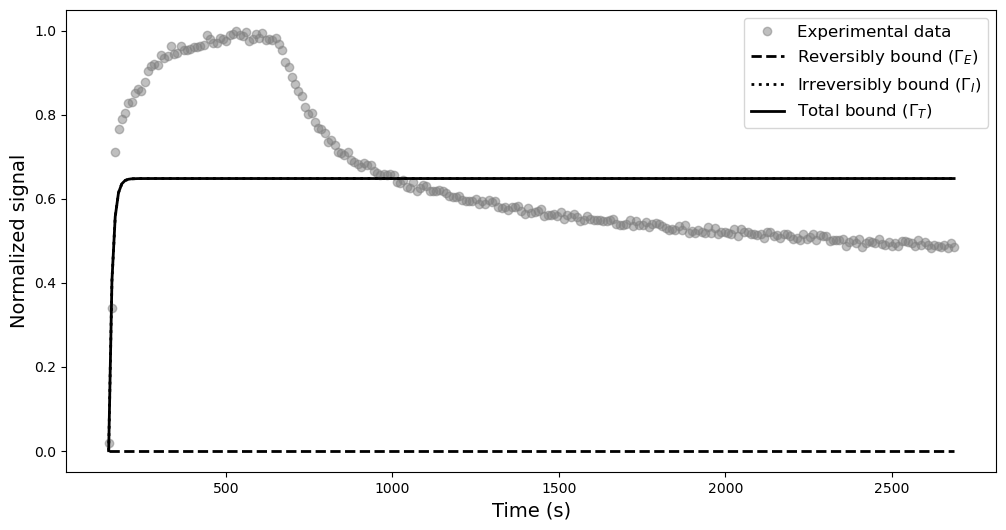

In [21]:
#@title  **analyze data**</font>

file_list = []
data_dir = 'refitting_for_paper'
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if 'CellulosePET' in file and ' 5 uM' in file:
            file_list.append(file)
global model_type, E_bulk
model_type = 'M4'

results = {
    'kon': [],
    'koff': [],
    'ki':[],
    'Gamma_max':[],
    'transition_time':[],
    'E_bulk': [],
    'R_max': [],
    'time_rescaled':[],
    'R_normalized_final':[],
    'MSE':[]
}

for file in file_list:
    E_bulk = float(file.split('-')[2].split(' ')[1])*1e-6 # in M
    print(f'E_bulk: {E_bulk:.2e} M')
    df = pd.read_csv(f'{data_dir}/{file}', sep='\t', decimal=',')
    time = df[df.columns[2]]*60
    R = df[df.columns[3]]
    #plt.plot(time, R)
    time_rescaled, R_normalized_final, R_max = process_data(time, R)
    bestpopt, error = fit_model(time_rescaled, R_normalized_final)
    results['kon'].append(bestpopt[0])
    results['koff'].append(bestpopt[1])
    results['ki'].append(bestpopt[2])
    results['Gamma_max'].append(bestpopt[3])
    results['transition_time'].append(bestpopt[4])
    results['MSE'].append(error)
    results['E_bulk'].append(E_bulk)
    results['R_max'].append(R_max)
    results['R_normalized_final'].append(R_normalized_final)
    results['time_rescaled'].append(time_rescaled)
    plot_best_popt(bestpopt, time_rescaled, R_normalized_final)
